# 8. Does Landsat see the decline?

Clipped biomass fell at the sites over 2011–2020, relative to the weather, and MODIS greenness in 500 m pixels did not (notebooks 2, 4 and 5). A 500 m pixel is a different piece of land from a clipping plot. Landsat's 30 m pixels are not, and its record starts in the 1980s. This notebook asks three things, under the rules that docs/design.md sets for the satellite check:

- **Scale.** Does Landsat greenness within 100 m of each plot decline over 2011–2020, after rain and temperature?
- **Agreement with the field.** How closely does Landsat follow biomass at the same sites, compared with MODIS?
- **The long record.** Is 2011–2020 unusual within the Landsat record?

A site's value for a year is the median NDVI of its observations from 1 July to 31 August, with at least half of the circle clear. Landsat 5, 8 and 9 are put on the Landsat 7 scale with the lines fitted in notebook 7, and Landsat 7 is used up to 2020. Greenness is then analysed like biomass: in logs, each site against its own average, with rain and summer temperature removed zone by zone.

- **Reads** `sites.csv`, `site_year.csv`, `flags.csv`, `modis_jul_aug_median.csv`, `landsat_conversions.csv` and the files in `landsat/`, all in `data/processed/`, and the weather table of the release.
- **Writes** `landsat_site_years.csv` to `data/processed/`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mn_desertification import data, greenness, paths, quality, trends
from mn_desertification.rules import (CHECK_FOOTPRINT_M, CHECK_MIN_CLEAR, FLOOR, LONG_MIN_YEARS, MAIN_YEARS,
                                      MIN_YEARS, ZONES)
from mn_desertification.weather import weather_remainders

site_info = pd.read_csv(paths.PROCESSED_DIR / "sites.csv")
weather = data.read_soum_weather()

def with_weather(values):
    """Attach each site's soum, zone and weather to a table of site-years."""
    return values.merge(site_info[["gid", "asid"]], on="gid").merge(weather, on=["asid", "year"], how="left")

# Every Landsat observation, one row a day, with its clear share, and the lines fitted in notebook 7
landsat = greenness.clearest_per_day(greenness.add_clear_share(greenness.read_landsat()))
conversions = greenness.read_conversions()
print("Observations:", len(landsat), "| converted sensors:", list(conversions))

Observations: 1202905 | converted sensors: ['landsat5', 'landsat8', 'landsat9']


In [2]:
def landsat_values(observations, index="ndvi", convert="fitted", **season):
    """Each site's value for each year, with the weather attached. Values must be above zero for logs."""
    if convert == "fitted":
        table = greenness.with_indices(observations, conversions=conversions)
    else:
        table = greenness.with_indices(observations, to_landsat7=(convert == "published"))
    values = greenness.seasonal_values(table, index, **season)
    return with_weather(values[values[index] > 0])

# The main version: the 100 m circle, at least half of it clear, Landsat 7 up to 2020, the fitted conversion,
# and the median of 1 July to 31 August
counted = greenness.counting(landsat)
main = landsat_values(counted)
print("Site-years with a value:", len(main), "| years:", main["year"].min(), "to", main["year"].max())
print("Median NDVI of the site-years:", round(main["ndvi"].median(), 3),
      "| median observations behind one:", main["n_observations"].median())
main[["gid", "year", "ndvi", "n_observations"]].to_csv(paths.PROCESSED_DIR / "landsat_site_years.csv", index=False)

Site-years with a value: 54384 | years: 1985 to 2024
Median NDVI of the site-years: 0.26 | median observations behind one: 4.0


## The decade 2011–2020

The same steps as for biomass: rain and summer temperature are removed, the trend of the yearly mean of all sites is fitted with its 95% range, and the sites whose own trend declines are counted.

In [3]:
def trend_row(name, table, value="ndvi", period=MAIN_YEARS, min_years=MIN_YEARS):
    """The trend of the yearly mean after rain and temperature, and the share of sites declining."""
    remainders = weather_remainders(table[table["year"].between(*period)], value)
    trend, low, high = trends.mean_trend(remainders)
    tested = trends.site_trends(remainders, min_years=min_years)
    row = {"series": name, "trend per decade": round(trend, 3), "95% range": f"{low:+.3f} to {high:+.3f}",
           "% per decade": round(float(trends.percent_per_decade(trend)), 1), "sites tested": len(tested),
           "sites declining": round((tested["p_decline"] < 0.05).mean(), 3)}
    return row, remainders

# Biomass as in notebook 2, and MODIS as extracted in notebook 5
flags = pd.read_csv(paths.PROCESSED_DIR / "flags.csv")
site_year = pd.read_csv(paths.PROCESSED_DIR / "site_year.csv").merge(weather[["asid", "year", "temp_summer"]],
                                                                    on=["asid", "year"], how="left")
biomass = quality.drop_flagged(site_year[site_year["year"].between(*MAIN_YEARS)], flags).copy()
biomass["bms_floored"] = biomass["bms"].clip(lower=FLOOR)
modis = with_weather(pd.read_csv(paths.PROCESSED_DIR / "modis_jul_aug_median.csv"))

rows, decade = [], {}
for name, table, value in [("biomass, clipped", biomass, "bms_floored"), ("MODIS, 500 m", modis, "ndvi"),
                           ("Landsat, 30 m", main, "ndvi")]:
    row, decade[name] = trend_row(name, table, value)
    rows.append(row)
pd.DataFrame(rows)

,series,trend per decade,95% range,% per decade,sites tested,sites declining
0,"biomass, clipped",-0.219,-0.403 to -0.034,-39.5,1250,0.205
1,"MODIS, 500 m",-0.007,-0.057 to +0.043,-1.6,1488,0.050
2,"Landsat, 30 m",-0.020,-0.088 to +0.048,-4.5,1488,0.080


Correlation of the yearly means:
                  biomass, clipped  MODIS, 500 m  Landsat, 30 m
biomass, clipped              1.00          0.74           0.79
MODIS, 500 m                  0.74          1.00           0.96
Landsat, 30 m                 0.79          0.96           1.00


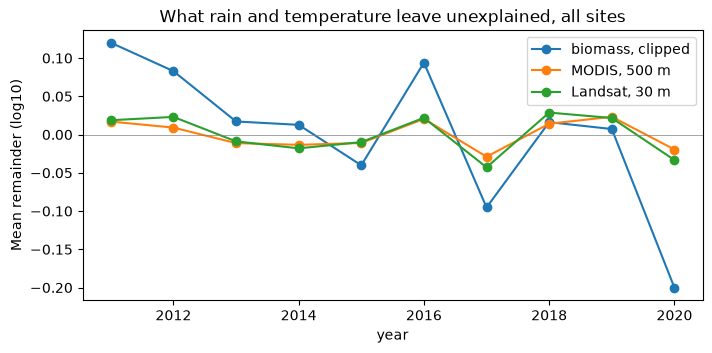

year,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
"biomass, clipped",0.120,0.083,0.017,0.013,-0.040,0.094,-0.095,0.016,0.007,-0.200
"MODIS, 500 m",0.017,0.009,-0.011,-0.013,-0.011,0.021,-0.029,0.014,0.023,-0.020
"Landsat, 30 m",0.019,0.023,-0.009,-0.018,-0.010,0.022,-0.043,0.029,0.022,-0.033


In [4]:
yearly = pd.DataFrame({name: trends.yearly_mean(remainders) for name, remainders in decade.items()})
print("Correlation of the yearly means:")
print(yearly.corr().round(2).to_string())

ax = yearly.plot(marker="o", figsize=(8, 3.5))
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("Mean remainder (log10)")
ax.set_title("What rain and temperature leave unexplained, all sites")
plt.show()
yearly.round(3).T

- **Landsat does not show the decline.** Its trend is −0.020 log10 per decade, about −5%, with a range that spans zero. Biomass fell by −0.219, about −40%.
- **8.0% of the sites decline in Landsat,** a little more than the 5% that chance gives. For biomass it is 20.5%.
- **The two satellites tell the same story.** Their yearly means correlate at 0.96. Both follow biomass through good and bad years, Landsat at 0.79 and MODIS at 0.74, but they move far less: in 2020 biomass is at −0.200, Landsat at −0.033 and MODIS at −0.020.

## The checks

Each row changes one thing in the main version.

In [5]:
# The checks of the design, one change at a time
versions = {
    "main": main,
    "published conversion": landsat_values(counted, convert="published"),
    "no conversion": landsat_values(counted, convert="none"),
    "Landsat 7 alone": landsat_values(counted[counted["sensor"] == "landsat7"], convert="none"),
    "August alone": landsat_values(counted, first=(8, 1), last=(8, 31)),
    "highest of June to September": landsat_values(counted, how="max", first=(6, 1), last=(9, 30)),
    "50 m circle": landsat_values(greenness.counting(landsat, radius_m=CHECK_FOOTPRINT_M)),
    "90% of the circle clear": landsat_values(greenness.counting(landsat, min_clear=CHECK_MIN_CLEAR)),
    "MSAVI": landsat_values(counted, index="msavi"),
    "mean of the pixels' NDVI, no conversion": landsat_values(counted, index="ndvi_pixels", convert="none"),
}
values_of = {"MSAVI": "msavi", "mean of the pixels' NDVI, no conversion": "ndvi_pixels"}
pd.DataFrame([trend_row(name, table, values_of.get(name, "ndvi"))[0] for name, table in versions.items()])

,series,trend per decade,95% range,% per decade,sites tested,sites declining
0,main,-0.020,-0.088 to +0.048,-4.5,1488,0.080
1,published conversion,0.026,-0.031 to +0.083,6.2,1488,0.043
2,no conversion,0.027,-0.031 to +0.085,6.4,1488,0.034
3,Landsat 7 alone,-0.016,-0.077 to +0.045,-3.6,1468,0.069
4,August alone,0.023,-0.058 to +0.105,5.5,1477,0.041
5,highest of June to September,0.018,-0.031 to +0.066,4.2,1488,0.038
6,50 m circle,-0.020,-0.089 to +0.048,-4.6,1488,0.081
7,90% of the circle clear,-0.020,-0.088 to +0.047,-4.5,1488,0.077
8,MSAVI,-0.007,-0.075 to +0.061,-1.5,1488,0.072
9,"mean of the pixels' NDVI, no conversion",0.027,-0.031 to +0.085,6.4,1488,0.034


- **The conversion decides the sign.** With the published conversion or none, the trend is +0.026 or +0.027. The difference from the main version is the step from Landsat 7 to Landsat 8 (notebook 7), not a change in the land.
- **Landsat 7 alone agrees with the main version,** at −0.016. It needs no conversion, so it confirms the fitted one.
- **The circle and the clear share change nothing,** and MSAVI gives −0.007.
- **The season matters.** August alone gives +0.023 and the highest value of June to September +0.018, about 0.04 above the main version.
- **Every range includes zero,** and no version comes near the −0.219 of biomass.

## Zone by zone

In [6]:
# Zone by zone: biomass against the two satellites
zone_rows = []
for zone in ZONES:
    row = {"zone": zone}
    for name, remainders in decade.items():
        in_zone = remainders[remainders["zone"] == zone]
        trend, low, high = trends.mean_trend(in_zone)
        row[name] = round(trend, 3)
        if name != "biomass, clipped":
            row[name + " range"] = f"{low:+.3f} to {high:+.3f}"
    row["sites"] = decade["Landsat, 30 m"].loc[decade["Landsat, 30 m"]["zone"] == zone, "gid"].nunique()
    zone_rows.append(row)
pd.DataFrame(zone_rows)

,zone,"biomass, clipped","MODIS, 500 m","MODIS, 500 m range","Landsat, 30 m","Landsat, 30 m range",sites
0,Desert zone,-0.412,-0.036,-0.111 to +0.039,-0.058,-0.131 to +0.015,113
1,Semi desert steppe zone,-0.434,-0.032,-0.080 to +0.016,-0.073,-0.131 to -0.015,325
2,Steppe zone,-0.233,-0.009,-0.067 to +0.049,-0.017,-0.087 to +0.054,627
3,Forest steppe zone,0.011,0.026,-0.053 to +0.105,0.028,-0.082 to +0.138,374
4,Mountain taiga belt,-0.024,0.003,-0.043 to +0.049,0.010,-0.058 to +0.078,49


- **Landsat declines a little in the two driest zones,** by −0.058 in the desert and −0.073 in the semi-desert steppe. That is about twice the MODIS trend there and about a sixth of the biomass decline.
- **Only the semi-desert steppe has a range that excludes zero.** With five zones looked at, one such range is weak evidence on its own.

## How closely each satellite follows biomass

Two rates, as in notebook 4. From year to year: how much the yearly mean of greenness moves when that of biomass moves. Between sites: how much greener a site with more biomass is. Each rate times the biomass trend gives the greenness trend to expect if greenness had followed biomass down.

In [7]:
# How closely does each satellite follow biomass: from year to year, and between sites?
biomass_trend = trends.mean_trend(decade["biomass, clipped"])[0]
site_biomass = np.log10(biomass["bms_floored"]).groupby(biomass["gid"]).mean()
follow_rows = []
for name, table in [("MODIS, 500 m", modis), ("Landsat, 30 m", main)]:
    ten_years = table[table["year"].between(*MAIN_YEARS)]
    site_means = pd.DataFrame({"biomass": site_biomass,
                               "greenness": np.log10(ten_years["ndvi"]).groupby(ten_years["gid"]).mean()}).dropna()
    year_slope = np.polyfit(yearly["biomass, clipped"], yearly[name], 1)[0]
    site_slope = np.polyfit(site_means["biomass"], site_means["greenness"], 1)[0]
    trend, low, high = trends.mean_trend(decade[name])
    follow_rows.append({"satellite": name,
                        "yearly correlation with biomass": round(yearly["biomass, clipped"].corr(yearly[name]), 2),
                        "year-to-year slope": round(year_slope, 2), "between-site slope": round(site_slope, 2),
                        "between-site correlation": round(site_means["biomass"].corr(site_means["greenness"]), 2),
                        "expected, year to year": round(year_slope * biomass_trend, 3),
                        "expected, between sites": round(site_slope * biomass_trend, 3),
                        "observed": round(trend, 3), "95% range": f"{low:+.3f} to {high:+.3f}"})
pd.DataFrame(follow_rows).T

,0,1
satellite,"MODIS, 500 m","Landsat, 30 m"
yearly correlation with biomass,0.74,0.79
year-to-year slope,0.15,0.22
between-site slope,0.63,0.72
between-site correlation,0.77,0.76
"expected, year to year",-0.032,-0.047
"expected, between sites",-0.137,-0.157
observed,-0.007,-0.02
95% range,-0.057 to +0.043,-0.088 to +0.048


- **Landsat follows biomass a little more closely than MODIS,** at 0.22 against 0.15 from year to year and 0.72 against 0.63 between sites.
- **At the year-to-year rate the decline could not have shown.** Landsat would have changed by −0.047, inside its range.
- **At the between-site rate it would have shown.** Landsat would have changed by −0.157, far outside its range.
- This is what notebook 4 concluded for MODIS. The finer pixels do not change it.

## The long record

The weather model is fitted to all 36 years from 1989, the first year from which every year has a value at 70% of the sites (notebook 6). Every ten-year window of the record then gets its own trend, to see where 2011–2020 stands among them. The last cell uses the standard form of the residual-trend method (Evans & Geerken 2004): each site's greenness against its own rain, and a trend through what is left.

            series  trend per decade        95% range  % per decade  sites tested  sites declining
Landsat, 1989-2024             0.015 +0.004 to +0.027           3.6          1488            0.036
  MODIS, 2000-2024             0.033 +0.020 to +0.045           7.8          1488            0.005


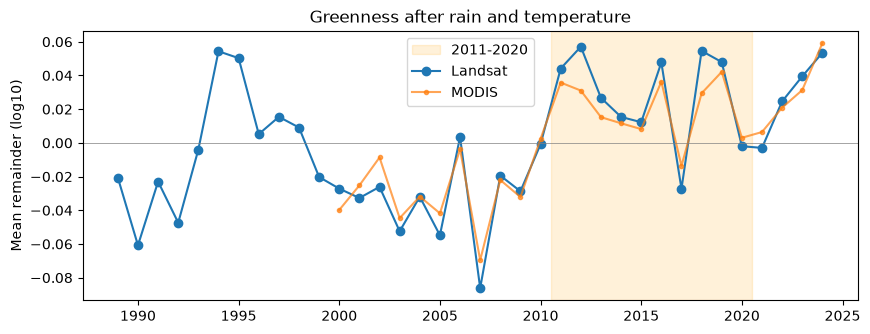

Ten-year windows: 27 | trend of 2011-2020: -0.026 | windows with a lower trend: 8
Lowest: 1994-2003 -0.112 | highest: 2004-2013 0.107


In [8]:
# The long record: 1989 to 2024, with the weather model fitted to all of it
LONG = (1989, 2024)
long_years = LONG[1] - LONG[0] + 1
long_row, long_remainders = trend_row("Landsat, 1989-2024", main, period=LONG, min_years=int(np.ceil(LONG_MIN_YEARS * long_years)))
modis_row, modis_long = trend_row("MODIS, 2000-2024", modis, period=(2000, 2024), min_years=20)
print(pd.DataFrame([long_row, modis_row]).to_string(index=False))

long_yearly = trends.yearly_mean(long_remainders)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axvspan(MAIN_YEARS[0] - 0.5, MAIN_YEARS[1] + 0.5, color="orange", alpha=0.15, label="2011-2020")
ax.plot(long_yearly.index, long_yearly.values, marker="o", label="Landsat")
ax.plot(trends.yearly_mean(modis_long), marker="o", markersize=3, alpha=0.7, label="MODIS")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("Mean remainder (log10)")
ax.set_title("Greenness after rain and temperature")
ax.legend()
plt.show()

# Every ten-year window of the record: how does 2011-2020 compare?
windows = pd.Series({f"{first}-{first + 9}": 10 * np.polyfit(range(first, first + 10), long_yearly.loc[first:first + 9], 1)[0]
                     for first in range(LONG[0], LONG[1] - 8)})
print("Ten-year windows:", len(windows), "| trend of 2011-2020:", round(windows["2011-2020"], 3),
      "| windows with a lower trend:", (windows < windows["2011-2020"]).sum())
print("Lowest:", windows.idxmin(), round(windows.min(), 3), "| highest:", windows.idxmax(), round(windows.max(), 3))

In [9]:
# The standard residual-trend method: each site against its own rain, 1989 to 2024
long_table = main[main["year"].between(*LONG)]
own = trends.residual_trends(long_table, "ndvi", min_years=int(np.ceil(LONG_MIN_YEARS * long_years)))
print("Sites:", len(own), "| median trend per decade:", round(own["decade"].median(), 3),
      "| declining (p < 0.05):", round((own["p_decline"] < 0.05).mean(), 3),
      "| rising (p > 0.95):", round((own["p_decline"] > 0.95).mean(), 3))
own.merge(site_info[["gid", "zone"]], on="gid").groupby("zone")["decade"].agg(["size", "median"]).reindex(ZONES).round(3)

Sites: 1488 | median trend per decade: 0.006 | declining (p < 0.05): 0.055 | rising (p > 0.95): 0.138


,size,median
zone,,
Desert zone,113,0.004
Semi desert steppe zone,325,0.006
Steppe zone,627,0.008
Forest steppe zone,374,0.004
Mountain taiga belt,49,0.006


- **Greenness rose slightly over the long record,** by +0.015 log10 per decade, with 3.6% of the sites declining.
- **2011–2020 is not unusual.** Its trend within the long record is −0.026, and 8 of the 27 ten-year windows have a lower one.
- **Site by site the picture is the same.** The median site rises by +0.006 per decade, 5.5% of the sites decline, as chance gives, and 13.8% rise.

## In short

- **Scale is not the reason the satellites miss the decline.** Within 100 m of the plots, Landsat greenness has a trend of −0.020 log10 per decade over 2011–2020, with a range from −0.088 to +0.048, against −0.219 for clipped biomass.
- **A small decline shows in the two driest zones,** about a sixth of the biomass decline.
- **Landsat could only have shown a decline at the rate that differences between sites imply,** and it shows none of that size.
- **2011–2020 is not unusual in the record since 1989.**
- **What this does not show.** By the rule of the design, the satellite stands in for field biomass only in what it reproduces over the years with field data. Landsat reproduces the good and bad years and not the decline, so the slight greening since 1989 does not show that biomass held up before 2007.